In [1]:
import os
import json
import time
from pathlib import Path
import shutil

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
import subprocess
import numpy as np
from tqdm import tqdm
from utils import prepare_data, get_variable_encoding_map


# Configuração para demonstração com dados de exemplo do projeto.
# Para execução com dados reais, crie a pasta data/ e ajuste os caminhos abaixo.
DATA_FILEPATH = '../data_example/samples/amstr_estabel.csv'
VARIABLE_MAP_FILEPATH = '../data_example/mapa_variaveis.json'

# Diretório para artefatos privados de execução (logs e resultados)
DATA_DIR = Path('../data')
DATA_DIR.mkdir(parents=True, exist_ok=True)
TMP_MEMORY_LOG_PATH = str(DATA_DIR / 'memory_log.txt')
RESULTS_PATH = str(DATA_DIR / 'check_recursos_results.json')

# Caminho do executável mprof no ambiente virtual (ajuste se necessário)
MPROF_PATH = shutil.which('mprof') or '../.venv/bin/mprof'


variable_map = json.load(open(VARIABLE_MAP_FILEPATH))
variable_map_df = pd.DataFrame.from_dict(variable_map, orient='index')
variable_map_df = variable_map_df.drop(columns=['condition', 'reference'], errors='ignore')

df = pd.read_csv(DATA_FILEPATH)

# Criando o ID de região do pais
estabel_ids = df['V010100'].astype(str)

df['region'] = estabel_ids.str[:1].astype('Int32')
df['uf'] = estabel_ids.str[:2].astype('Int32')
df['city'] = estabel_ids.str[:7].astype('Int32')
df['district'] = estabel_ids.str[:9].astype('Int32')
df['sub_district'] = estabel_ids.str[:13].astype('Int64')

# Removendo valores de identificadores únicos da base
df.drop(['V010100', 'NUM_QUADRA', 'NUM_FACE', 'V010800'], axis=1, inplace=True)

total_samples = df.shape[0]

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    10 non-null     int64  
 1   V011300       10 non-null     object 
 2   V01150000     10 non-null     int64  
 3   V01150101     4 non-null      float64
 4   V01150102     5 non-null      float64
 5   V01170100     10 non-null     int64  
 6   V01170500     10 non-null     int64  
 7   V01170501     10 non-null     int64  
 8   V02010000     10 non-null     int64  
 9   V02020000     10 non-null     int64  
 10  V33010600     10 non-null     int64  
 11  V33010700     10 non-null     int64  
 12  V41010100     10 non-null     int64  
 13  region        10 non-null     Int32  
 14  uf            10 non-null     Int32  
 15  city          10 non-null     Int32  
 16  district      10 non-null     Int32  
 17  sub_district  10 non-null     Int64  
dtypes: Int32(4), Int64(1), float64(2)

In [2]:
categorical_variables_map = get_variable_encoding_map(df, variable_map_df)

numerical_variables_map = {
    'variables': list(df.select_dtypes(include=[np.number]).columns),
    'encoding': "minmax",
    'missing_treatment': "zero"
}

X, feature_names, num_features, cat_features = prepare_data(df, numerical_variables_map, categorical_variables_map, variable_map)

X.shape

/home/carlos_rocha/Documentos/IBGE/ibge-censo-agro-research/02 - Recursos/utils.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(value, inplace=True)


(10, 9)

In [ ]:
MODELS = {
    "ECOD": {"type": "Probabilistic"}, 
    "COPOD": {"type": "Probabilistic"},
    "PCA": {"type": "Linear"},
    "KPCA": {"type": "Linear"},
    "HBOS": {"type": "Proximity-Based"},
    "CBLOF": {"type": "Proximity-Based"},
    "IForest": {"type": "Outlier Ensembles"},
    "DIF": {"type": "Outlier Ensembles"},
    "R-Graph": {"type": "Graph-based"},
    "LUNAR": {"type": "Graph-based"},
    "VAE": {"type": "Neural Networks"},
    "ALAD": {"type": "Neural Networks"},
}


results = [] if not os.path.exists(RESULTS_PATH) else json.load(open(RESULTS_PATH))

experiments = list(itertools.product(MODELS.keys(), [2, 3, 5], [0.001, 0.01, 0.1, 0.2, 0.5, 1]))
experiments.sort(key=lambda x: (x[0], x[1], x[2]))

# Ambiente limpo para subprocessos: força backend não-interativo do matplotlib
subprocess_env = os.environ.copy()
subprocess_env['MPLBACKEND'] = 'Agg'

for model_name, seed, dataset_ratio in (pbar := tqdm(experiments)):

    if os.path.exists(TMP_MEMORY_LOG_PATH):
        os.remove(TMP_MEMORY_LOG_PATH)

    pbar.set_description(f"Seed: {seed}, Ratio: {dataset_ratio}, Model: {model_name}")

    model_info = MODELS[model_name]
    model_type = model_info["type"]

    # check if this configuration was already run
    if any(r for r in results if r["model"] == model_name and r["dataset_ratio"] == dataset_ratio and r["seed"] == seed):
        # print(f"Skipping already run configuration: model={model_name}, dataset_ratio={dataset_ratio}, seed={seed}")
        continue

    start_time = time.time()

    cmd = f"{MPROF_PATH} run --output={TMP_MEMORY_LOG_PATH} check_recursos.py --model={model_name} --dataset_ratio={dataset_ratio} \
                --seed={seed} --data_filepath={DATA_FILEPATH} --variable_map_filepath={VARIABLE_MAP_FILEPATH} > /dev/null"

    try:
        output = subprocess.check_output(cmd, shell=True, stderr=subprocess.STDOUT, timeout=1800, env=subprocess_env) # 30 minutes timeout
        output_msg = output.decode()
    except Exception as e:
        output_msg = str(e)
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    # get peak memory usage
    peak_memory = 0.0
    if os.path.exists(TMP_MEMORY_LOG_PATH):
        with open(TMP_MEMORY_LOG_PATH, 'r') as f:
            lines = f.readlines()
            mem_usages = [float(line.split()[1]) for line in lines if line.startswith('MEM')]
            peak_memory = max(mem_usages) if mem_usages else 0.0

    result = {
        "model": model_name,
        "type": model_type,
        "dataset_ratio": dataset_ratio,
        "num_samples": int(total_samples * dataset_ratio),
        "seed": seed,
        "time_in_seconds": elapsed_time,
        "peak_memory_in_mb": peak_memory,
        "output_msg": output_msg,
    }
    results.append(result)
    # print(f"Result: {result}")

    # save results after each run
    with open(RESULTS_PATH, 'w') as f:
        json.dump(results, f, indent=4)


Seed: 2, Ratio: 0.001, Model: ALAD:   0%|          | 0/216 [00:00<?, ?it/s]

Seed: 5, Ratio: 1, Model: VAE: 100%|██████████| 216/216 [13:52<00:00,  3.86s/it]        


In [4]:
results_df = pd.DataFrame(results)
results_df['peak_memory_in_gb'] = results_df['peak_memory_in_mb'] / 1024
results_df['time_in_minutes'] = results_df['time_in_seconds'] / 60
results_df

,model,type,dataset_ratio,num_samples,seed,time_in_seconds,peak_memory_in_mb,output_msg,peak_memory_in_gb,time_in_minutes
0,ALAD,Neural Networks,0.001,0,2,3.506438,693.570312,"Traceback (most recent call last):\n File ""/h...",0.677315,0.058441
1,ALAD,Neural Networks,0.010,0,2,3.558756,701.648438,"Traceback (most recent call last):\n File ""/h...",0.685204,0.059313
2,ALAD,Neural Networks,0.100,1,2,5.350936,812.300781,,0.793262,0.089182
3,ALAD,Neural Networks,0.200,2,2,5.277083,931.660156,,0.909824,0.087951
4,ALAD,Neural Networks,0.500,5,2,5.529586,813.210938,,0.794151,0.092160
...,...,...,...,...,...,...,...,...,...,...
211,VAE,Neural Networks,0.010,0,5,3.461854,701.679688,"Traceback (most recent call last):\n File ""/h...",0.685234,0.057698
212,VAE,Neural Networks,0.100,1,5,4.381226,808.410156,"Traceback (most recent call last):\n File ""/h...",0.789463,0.073020
213,VAE,Neural Networks,0.200,2,5,4.478136,800.261719,"Traceback (most recent call last):\n File ""/h...",0.781506,0.074636
214,VAE,Neural Networks,0.500,5,5,4.451261,800.328125,"Traceback (most recent call last):\n File ""/h...",0.781570,0.074188


In [7]:
# removendo experimentos que deram falha (output_msg não está vazio)
filtered_results_df = results_df[results_df['output_msg'].str.strip() == '']
filtered_results_df

,model,type,dataset_ratio,num_samples,seed,time_in_seconds,peak_memory_in_mb,output_msg,peak_memory_in_gb,time_in_minutes
2,ALAD,Neural Networks,0.1,1,2,5.350936,812.300781,,0.793262,0.089182
3,ALAD,Neural Networks,0.2,2,2,5.277083,931.660156,,0.909824,0.087951
4,ALAD,Neural Networks,0.5,5,2,5.529586,813.210938,,0.794151,0.092160
5,ALAD,Neural Networks,1.0,10,2,5.955626,805.242188,,0.786369,0.099260
8,ALAD,Neural Networks,0.1,1,3,5.486567,812.234375,,0.793198,0.091443
...,...,...,...,...,...,...,...,...,...,...
190,R-Graph,Graph-based,0.5,5,3,3.450949,695.144531,,0.678852,0.057516
191,R-Graph,Graph-based,1.0,10,3,2.488610,703.074219,,0.686596,0.041477
195,R-Graph,Graph-based,0.2,2,5,3.226916,702.996094,,0.686520,0.053782
196,R-Graph,Graph-based,0.5,5,5,3.025559,703.148438,,0.686668,0.050426


In [8]:
# criar dataframe com o tempo e memória média, com desvio padrão, por modelo apenas para os experimentos com dataset_ratio=1

summary_df = filtered_results_df[filtered_results_df['dataset_ratio'] == 1.0].groupby('model').agg(
    avg_time_in_minutes=('time_in_minutes', 'mean'),
    std_time_in_minutes=('time_in_minutes', 'std'),
    avg_peak_memory_in_gb=('peak_memory_in_gb', 'mean'),
    std_peak_memory_in_gb=('peak_memory_in_gb', 'std'),
).reset_index()

summary_df

,model,avg_time_in_minutes,std_time_in_minutes,avg_peak_memory_in_gb,std_peak_memory_in_gb
0,ALAD,0.095538,0.008575,0.791665,0.004590
1,CBLOF,0.081449,0.006358,0.830227,0.068996
2,COPOD,0.059041,0.005882,0.728188,0.003869
3,DIF,0.066159,0.007359,0.711711,0.016817
4,ECOD,0.068124,0.004419,0.732140,0.000405
5,HBOS,0.101147,0.001089,0.761635,0.000547
6,IForest,0.056029,0.003220,0.682854,0.004411
7,KPCA,0.055648,0.001651,0.744442,0.051237
8,LUNAR,0.098702,0.005384,0.840918,0.068756
9,PCA,0.057378,0.001468,0.731738,0.065354


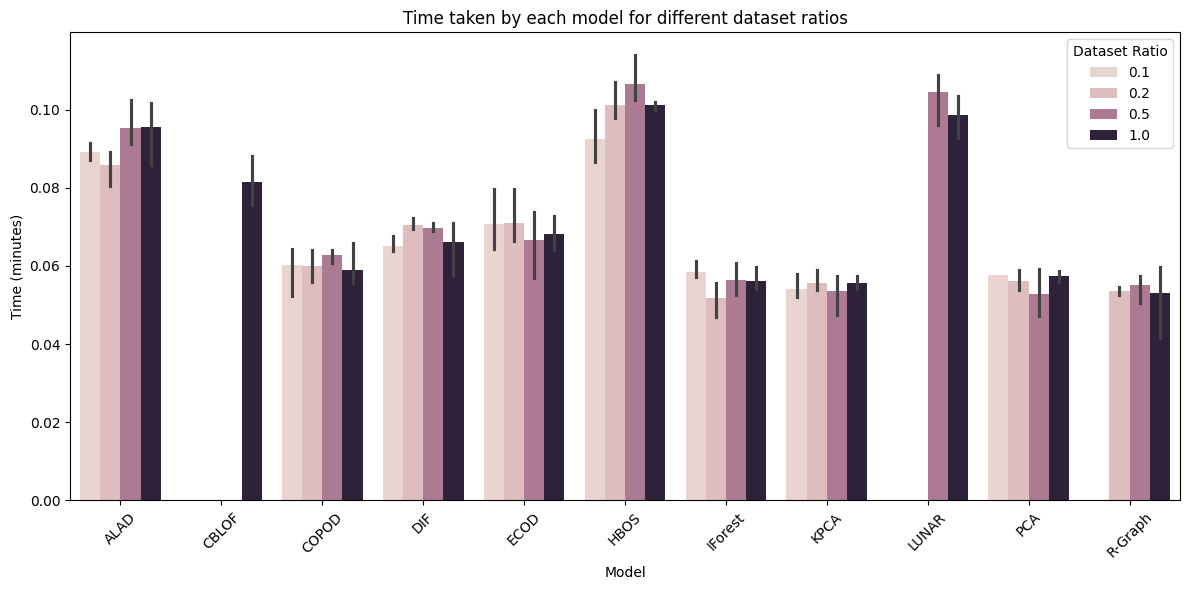

In [9]:
# time bar
plt.figure(figsize=(12, 6))
sns.barplot(data=filtered_results_df, x='model', y='time_in_minutes', hue='dataset_ratio')
plt.title('Time taken by each model for different dataset ratios')
plt.ylabel('Time (minutes)')
plt.xlabel('Model')
plt.legend(title='Dataset Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

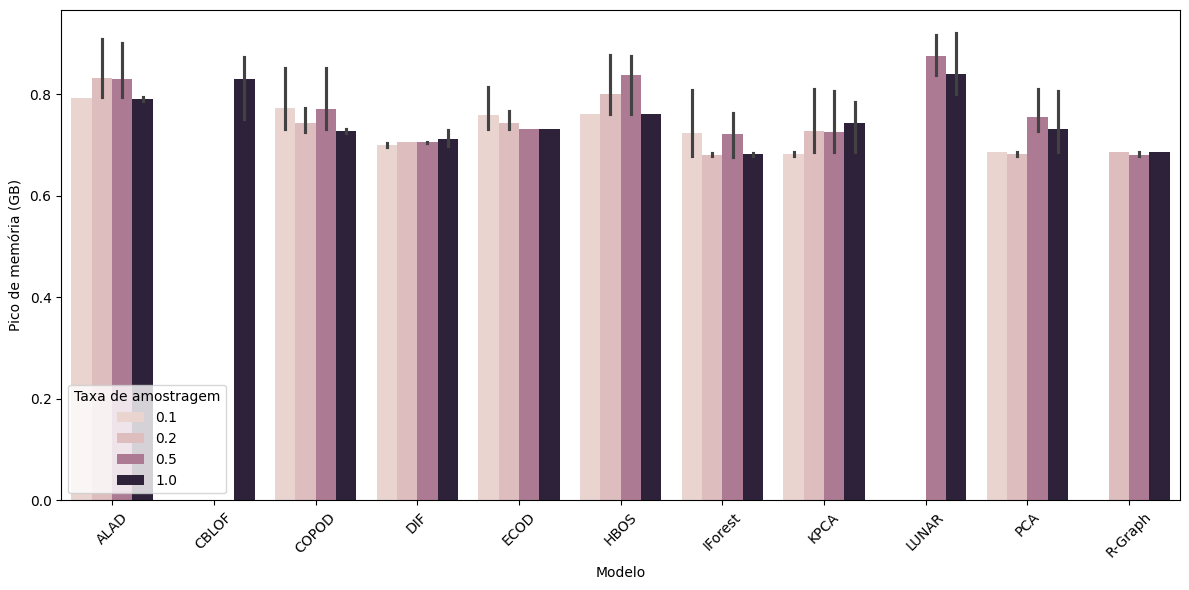

In [10]:
# memory bar
plt.figure(figsize=(12, 6))
sns.barplot(data=filtered_results_df, x='model', y='peak_memory_in_gb', hue='dataset_ratio')
# plt.title('Pico de uso de memória para cada modelo em diferentes taxas de amostragem')
plt.ylabel('Pico de memória (GB)')
plt.xlabel('Modelo')
plt.legend(title='Taxa de amostragem')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

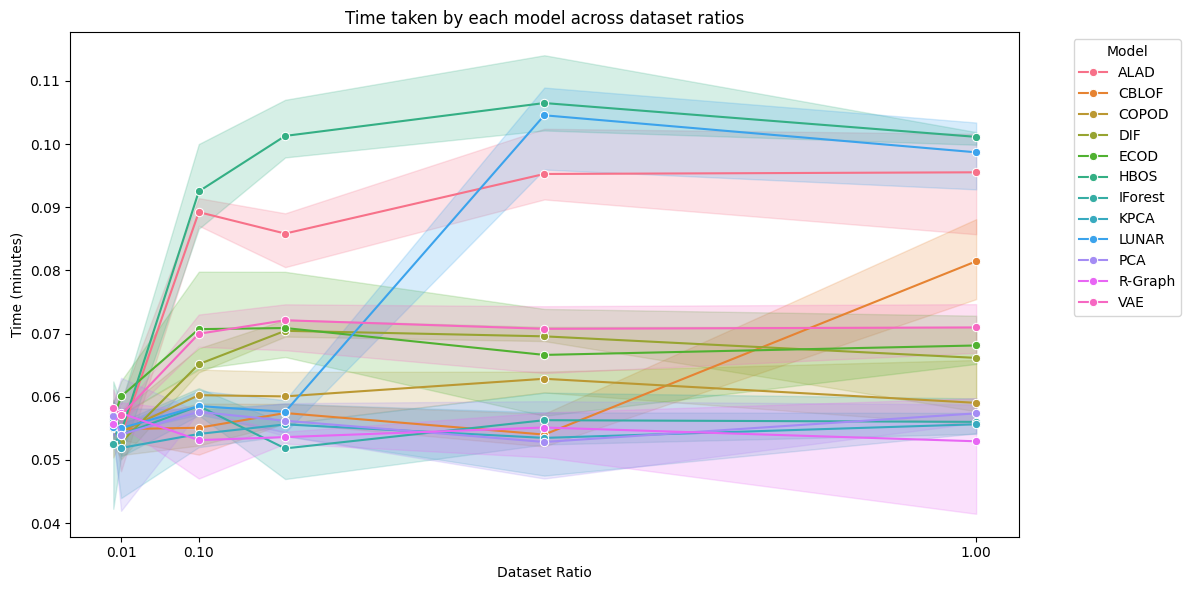

In [11]:

# plot line chart (time)
plt.figure(figsize=(12, 6))
sns.lineplot(data=results_df, x='dataset_ratio', y='time_in_minutes', hue='model', marker='o')
plt.title('Time taken by each model across dataset ratios')
plt.ylabel('Time (minutes)')
plt.xlabel('Dataset Ratio')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks([0.01, 0.1, 1])
plt.tight_layout()
plt.show()


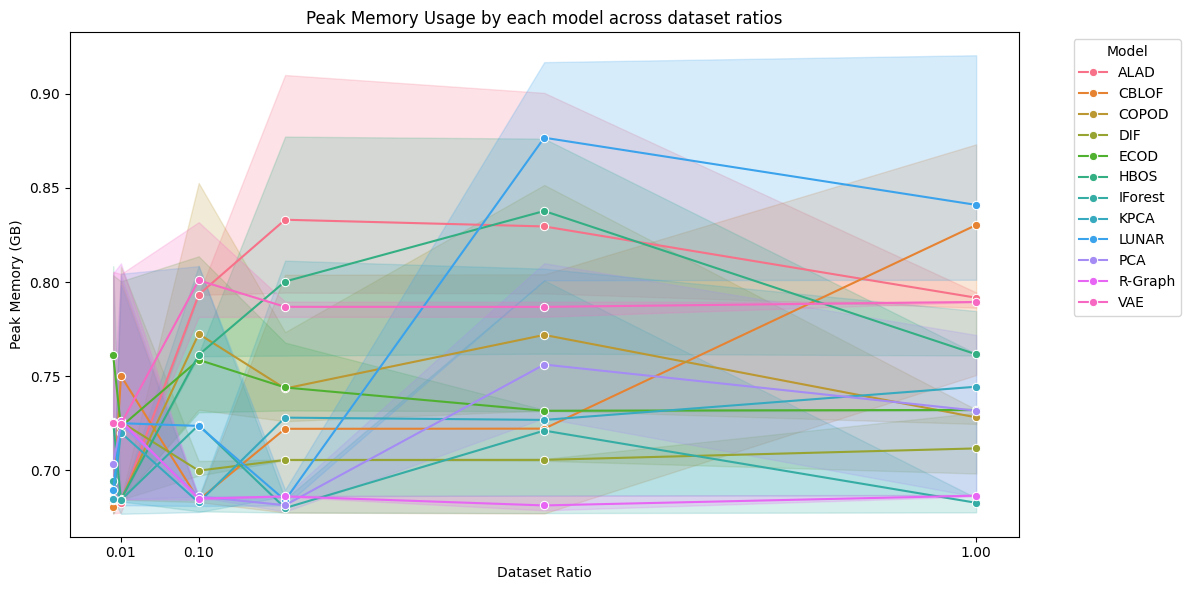

In [12]:

# plot line chart (memory)
plt.figure(figsize=(12, 6))
sns.lineplot(data=results_df, x='dataset_ratio', y='peak_memory_in_gb', hue='model', marker='o')
plt.title('Peak Memory Usage by each model across dataset ratios')
plt.ylabel('Peak Memory (GB)')
plt.xlabel('Dataset Ratio')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks([0.01, 0.1, 1])
plt.tight_layout()
plt.show()